In [1]:
# Ref: https://www.kaggle.com/code/ahnc2171/cmi-nnn/notebook
!pip install tqdm scipy --quiet

import os
import random
import numpy as np
import pandas as pd
import polars as pl
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from torch.nn.utils import clip_grad_norm_

from sklearn.model_selection import GroupKFold
from sklearn.metrics import f1_score
from tqdm.auto import tqdm
from copy import deepcopy
#import kaggle_evaluation.cmi_inference_server
from scipy.spatial.transform import Rotation as R

import warnings
warnings.filterwarnings("ignore")


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_seed(42)

device = 'mps'
print("Device:", device)

/Users/ashhadulislam/miniconda3/envs/py310/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Device: mps


In [2]:
train_df=pd.read_csv('data/extractedPhysicsFeatures_train.csv')

In [3]:
train_df.head()


,row_id,sequence_type,sequence_id,sequence_counter,subject,orientation,behavior,phase,gesture,acc_x,...,angular_vel_y,angular_vel_z,linear_acc_x,linear_acc_y,linear_acc_z,jerk_x,jerk_y,jerk_z,acc_mag,jerk_mag
0,SEQ_000007_000000,Target,SEQ_000007,0,SUBJ_059520,Seated Lean Non Dom - FACE DOWN,Relaxes and moves hand to target location,Transition,Cheek - pinch skin,0.397627,...,0.510388,0.164759,-0.307147,0.086633,-0.185359,-0.023208,-0.010836,0.015704,-0.817480,-1.152084
1,SEQ_000007_000001,Target,SEQ_000007,1,SUBJ_059520,Seated Lean Non Dom - FACE DOWN,Relaxes and moves hand to target location,Transition,Cheek - pinch skin,0.596723,...,2.526555,2.132639,0.259833,0.361276,-0.976324,0.476966,0.278038,-0.698970,-0.077394,-0.243341
2,SEQ_000007_000002,Target,SEQ_000007,2,SUBJ_059520,Seated Lean Non Dom - FACE DOWN,Relaxes and moves hand to target location,Transition,Cheek - pinch skin,-0.322632,...,1.539116,3.803274,-0.805797,0.769870,-0.561961,-0.963277,0.418930,0.390100,-0.137172,-0.248996
3,SEQ_000007_000003,Target,SEQ_000007,3,SUBJ_059520,Seated Lean Non Dom - FACE DOWN,Relaxes and moves hand to target location,Transition,Cheek - pinch skin,0.336142,...,2.473158,2.394515,0.835565,1.347347,-1.042372,1.424756,0.596563,-0.418370,0.481421,0.160637
4,SEQ_000007_000004,Target,SEQ_000007,4,SUBJ_059520,Seated Lean Non Dom - FACE DOWN,Relaxes and moves hand to target location,Transition,Cheek - pinch skin,-0.439748,...,0.632923,1.532569,1.751127,0.828508,0.751455,0.784475,-0.556560,1.636512,0.658352,0.793776


In [4]:
for col in train_df.columns:
    print(col)

row_id
sequence_type
sequence_id
sequence_counter
subject
orientation
behavior
phase
gesture
acc_x
acc_y
acc_z
rot_w
rot_x
rot_y
rot_z
thm_1
thm_2
thm_3
thm_4
thm_5
tof_1_v0
tof_1_v1
tof_1_v2
tof_1_v3
tof_1_v4
tof_1_v5
tof_1_v6
tof_1_v7
tof_1_v8
tof_1_v9
tof_1_v10
tof_1_v11
tof_1_v12
tof_1_v13
tof_1_v14
tof_1_v15
tof_1_v16
tof_1_v17
tof_1_v18
tof_1_v19
tof_1_v20
tof_1_v21
tof_1_v22
tof_1_v23
tof_1_v24
tof_1_v25
tof_1_v26
tof_1_v27
tof_1_v28
tof_1_v29
tof_1_v30
tof_1_v31
tof_1_v32
tof_1_v33
tof_1_v34
tof_1_v35
tof_1_v36
tof_1_v37
tof_1_v38
tof_1_v39
tof_1_v40
tof_1_v41
tof_1_v42
tof_1_v43
tof_1_v44
tof_1_v45
tof_1_v46
tof_1_v47
tof_1_v48
tof_1_v49
tof_1_v50
tof_1_v51
tof_1_v52
tof_1_v53
tof_1_v54
tof_1_v55
tof_1_v56
tof_1_v57
tof_1_v58
tof_1_v59
tof_1_v60
tof_1_v61
tof_1_v62
tof_1_v63
tof_2_v0
tof_2_v1
tof_2_v2
tof_2_v3
tof_2_v4
tof_2_v5
tof_2_v6
tof_2_v7
tof_2_v8
tof_2_v9
tof_2_v10
tof_2_v11
tof_2_v12
tof_2_v13
tof_2_v14
tof_2_v15
tof_2_v16
tof_2_v17
tof_2_v18
tof_2_v19
tof_2_v20
tof_2

In [5]:
IMU_BASE_COLS = [
    "acc_x","acc_y","acc_z",
    "rot_w","rot_x","rot_y","rot_z"
]

IMU_FEATURE_NAMES = [
    "acc_x", "acc_y", "acc_z",
    "rot_6d_0", "rot_6d_1", "rot_6d_2",
    "rot_6d_3", "rot_6d_4", "rot_6d_5",
    "angular_vel_x", "angular_vel_y", "angular_vel_z",
    "linear_acc_x", "linear_acc_y", "linear_acc_z",
    "jerk_x", "jerk_y", "jerk_z",
    "acc_mag", "jerk_mag",
]

In [6]:
IMU_FEATURE_COLS = IMU_FEATURE_NAMES

## adding the base columns here as well
for cols in [IMU_FEATURE_COLS,IMU_BASE_COLS]:
    if len(cols) == 0:
        continue
    train_df[cols] = train_df[cols].replace([np.inf, -np.inf], np.nan)
    train_df[cols] = train_df[cols].ffill().bfill().fillna(0)

print("NaN IMU:", train_df[IMU_FEATURE_COLS].isna().sum().sum())


NaN IMU: 0


In [7]:
train_df[IMU_BASE_COLS].isna().sum()

acc_x    0
acc_y    0
acc_z    0
rot_w    0
rot_x    0
rot_y    0
rot_z    0
dtype: int64

In [8]:
# ============================================================
# 5. TẠO NHÃN BINARY + MULTICLASS
# ============================================================
gestures = sorted(train_df["gesture"].unique())
gesture2idx = {g: i for i, g in enumerate(gestures)}
idx2gesture = {i: g for g, i in gesture2idx.items()}
num_classes = len(gestures)
print("Num gesture classes:", num_classes)

train_df["y_multi"] = train_df["gesture"].map(gesture2idx).astype(int)
train_df["y_bin"]   = (train_df["sequence_type"] == "target").astype(int)

# ============================================================
# 5b. METRIC CHUẨN: HIERARCHICAL MACRO F1 (BINARY + MULTICLASS)
# ============================================================
TARGET_GESTURES = [
    'Above ear - pull hair',
    'Cheek - pinch skin',
    'Eyebrow - pull hair',
    'Eyelash - pull hair',
    'Forehead - pull hairline',
    'Forehead - scratch',
    'Neck - pinch skin',
    'Neck - scratch',
]

NON_TARGET_GESTURES = [
    'Write name on leg',
    'Wave hello',
    'Glasses on/off',
    'Text on phone',
    'Write name in air',
    'Feel around in tray and pull out an object',
    'Scratch knee/leg skin',
    'Pull air toward your face',
    'Drink from bottle/cup',
    'Pinch knee/leg skin',
]

ALL_GESTURES_SET = set(TARGET_GESTURES + NON_TARGET_GESTURES)

def hierarchical_f1_from_labels(y_true_gesture, y_pred_gesture) -> float:
    y_true_gesture = np.asarray(y_true_gesture, dtype=object)
    y_pred_gesture = np.asarray(y_pred_gesture, dtype=object)

    # Binary labels (Target vs Non-Target) dựa trên gesture list
    y_true_bin = np.isin(y_true_gesture, TARGET_GESTURES)
    y_pred_bin = np.isin(y_pred_gesture, TARGET_GESTURES)

    f1_binary = f1_score(
        y_true_bin.astype(int),
        y_pred_bin.astype(int),
        pos_label=1,
        average="binary",
        zero_division=0,
    )

    # Multi-class: 8 target gesture + 1 lớp 'non_target'
    def map_to_mc(g):
        return g if g in TARGET_GESTURES else 'non_target'

    y_true_mc = np.array([map_to_mc(g) for g in y_true_gesture], dtype=object)
    y_pred_mc = np.array([map_to_mc(g) for g in y_pred_gesture], dtype=object)

    f1_macro = f1_score(
        y_true_mc,
        y_pred_mc,
        average="macro",
        zero_division=0,
    )

    return 0.5 * f1_binary + 0.5 * f1_macro


Num gesture classes: 18


In [9]:
class IMUOnlyDataset(Dataset):
    def __init__(
        self,
        df: pd.DataFrame,
        is_train: bool = True,
        augment: bool = False,
        mixup_prob: float = 0.3,
    ):
        self.is_train = is_train
        self.augment = augment
        self.mixup_prob = mixup_prob

        self.sequences = []

        for seq_id, grp in df.groupby("sequence_id"):
            grp = grp.sort_values("sequence_counter")

            x_imu_base = grp[IMU_BASE_COLS].values.astype(np.float32)
            x_imu_feat = grp[IMU_FEATURE_NAMES].values.astype(np.float32)

            subject = grp["subject"].iloc[0]

            if is_train:
                y_bin   = int(grp["y_bin"].iloc[0])
                y_multi = int(grp["y_multi"].iloc[0])
            else:
                y_bin   = -1
                y_multi = -1

            self.sequences.append(
                (x_imu_base, x_imu_feat, y_bin, y_multi, subject, seq_id)
            )

        # Needed for class-conditional mixup
        self.indices_by_class = {}
        for idx, (_, _, _, y_multi, _, _) in enumerate(self.sequences):
            if y_multi >= 0:
                self.indices_by_class.setdefault(y_multi, []).append(idx)

    def __len__(self):
        return len(self.sequences)
    
    def _augment(self, x_imu_base: np.ndarray):
        T = x_imu_base.shape[0]

        # Gaussian noise
        if np.random.rand() < 0.5:
            noise = np.random.normal(0, 0.02, size=x_imu_base.shape).astype(np.float32)
            x_imu_base = x_imu_base + noise

        # Small rotation of acceleration only
        if np.random.rand() < 0.5:
            acc = x_imu_base[:, 0:3]
            theta = np.random.uniform(-0.15, 0.15)
            cos_t, sin_t = np.cos(theta), np.sin(theta)
            Rz = np.array(
                [[cos_t, -sin_t, 0.0],
                 [sin_t,  cos_t, 0.0],
                 [0.0,    0.0,   1.0]],
                dtype=np.float32
            )
            x_imu_base[:, 0:3] = acc @ Rz.T

        # Temporal dropout
        if np.random.rand() < 0.3 and T > 10:
            win = np.random.randint(max(2, T // 20), max(3, T // 10))
            start = np.random.randint(0, max(1, T - win))
            x_imu_base[start:start+win] = 0.0

        return x_imu_base    
    

    def _sequence_mixup(self, idx, x_imu_base, y_multi):
        if y_multi < 0:
            return x_imu_base

        class_indices = self.indices_by_class.get(y_multi, [])
        if len(class_indices) <= 1:
            return x_imu_base

        partner_idx = random.choice([i for i in class_indices if i != idx])
        x2_base, _, _, _, _, _ = self.sequences[partner_idx]

        L = min(len(x_imu_base), len(x2_base))
        lam = np.random.beta(0.4, 0.4)

        return lam * x_imu_base[:L] + (1 - lam) * x2_base[:L]    
    

    def __getitem__(self, idx):
        x_base, x_feat, y_bin, y_multi, subject, seq_id = self.sequences[idx]

        if self.is_train and self.augment:
            x_base = self._augment(x_base)
            if self.mixup_prob > 0 and np.random.rand() < self.mixup_prob:
                x_base = self._sequence_mixup(idx, x_base, y_multi)

        return (
            torch.tensor(x_base, dtype=torch.float32),
            torch.tensor(x_feat, dtype=torch.float32),
            torch.tensor(y_bin, dtype=torch.float32),
            torch.tensor(y_multi, dtype=torch.long),
            subject,
            seq_id,
        )    
    


def imu_only_collate_fn(batch):
    x_base, x_feat, yb, ym, subj, seq = zip(*batch)

    lengths = torch.tensor([x.shape[0] for x in x_base], dtype=torch.long)

    x_base_pad = pad_sequence(x_base, batch_first=True)
    x_feat_pad = pad_sequence(x_feat, batch_first=True)

    return (
        x_base_pad,     # (B, T, 7)
        lengths,        # (B,)
        x_feat_pad,     # (B, T, D_feat)  ← optional, for probes
        torch.stack(yb),
        torch.stack(ym),
        subj,
        seq,
    )


In [10]:
class ResBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3):
        super().__init__()
        padding = kernel_size // 2

        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size, padding=padding, bias=False)
        self.bn1   = nn.BatchNorm1d(out_ch)

        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size, padding=padding, bias=False)
        self.bn2   = nn.BatchNorm1d(out_ch)

        self.skip = (
            nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_ch),
            )
            if in_ch != out_ch
            else nn.Identity()
        )

    def forward(self, x):
        identity = self.skip(x)
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return F.relu(out + identity)
    


class ResNet1DEncoder(nn.Module):
    def __init__(self, in_ch=7, latent_dim=64):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv1d(in_ch, 64, kernel_size=7, padding=3, bias=False),
            nn.BatchNorm1d(64),
            nn.ReLU(),
        )

        self.block1 = ResBlock1D(64, 64)
        self.block2 = ResBlock1D(64, 128)
        self.block3 = ResBlock1D(128, latent_dim)

    def forward(self, x):
        # x: (B, T, C) → (B, C, T)
        x = x.transpose(1, 2)
        x = self.stem(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        return x.transpose(1, 2)
    



class ResNet1DDecoder(nn.Module):
    def __init__(self, latent_dim=64, out_ch=7):
        super().__init__()

        self.block1 = ResBlock1D(latent_dim, 128)
        self.block2 = ResBlock1D(128, 64)
        self.block3 = ResBlock1D(64, 64)

        self.out = nn.Conv1d(64, out_ch, kernel_size=7, padding=3)

    def forward(self, z):
        # z: (B, T, D) → (B, D, T)
        z = z.transpose(1, 2)
        z = self.block1(z)
        z = self.block2(z)
        z = self.block3(z)
        x_hat = self.out(z)
        return x_hat.transpose(1, 2)


class ResNet1DAutoEncoder(nn.Module):
    def __init__(self, in_ch=7, latent_dim=64):
        super().__init__()
        self.encoder = ResNet1DEncoder(in_ch, latent_dim)
        self.decoder = ResNet1DDecoder(latent_dim, in_ch)

    def forward(self, x):
        z = self.encoder(x)      # (B, T, D)
        x_hat = self.decoder(z)  # (B, T, C)
        return x_hat, z    



def masked_mse_loss(x_hat, x, lengths):
    """
    x_hat, x: (B, T, C)
    lengths: (B,)
    """
    B, T, C = x.shape
    mask = torch.arange(T, device=x.device)[None, :] < lengths[:, None]
    mask = mask.unsqueeze(-1).float()  # (B, T, 1)

    loss = ((x_hat - x) ** 2 * mask).sum() / mask.sum()
    return loss



In [11]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    n_batches = 0

    for x_imu, lengths, *_ in loader:

        #print(x_imu.shape)
        x_imu = x_imu.to(device)
        lengths = lengths.to(device)

        optimizer.zero_grad()
        x_hat, z = model(x_imu)
        #print(x_hat.shape)

        loss = masked_mse_loss(x_hat, x_imu, lengths)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        total_loss += loss.item()
        n_batches += 1

    return total_loss / max(1, n_batches)



def eval_one_epoch(model, loader, device):
    model.eval()
    total_loss = 0.0
    n_batches = 0

    with torch.no_grad():
        for x_imu, lengths, *_ in loader:
            x_imu = x_imu.to(device)
            lengths = lengths.to(device)

            x_hat, z = model(x_imu)
            loss = masked_mse_loss(x_hat, x_imu, lengths)

            total_loss += loss.item()
            n_batches += 1

    return total_loss / max(1, n_batches)




Train+Val sequences: 6422
TEST sequences: 1729

========== FOLD 1 ==========
  #seq train: 5709 - #seq val: 713
5709 713

EPOCH 1/20
Train Loss: 0.79060 | Val Loss: 0.32416

EPOCH 2/20
Train Loss: 0.25483 | Val Loss: 0.19713

EPOCH 3/20
Train Loss: 0.17661 | Val Loss: 0.17450

EPOCH 4/20
Train Loss: 0.15137 | Val Loss: 0.14027

EPOCH 5/20
Train Loss: 0.11699 | Val Loss: 0.11567

EPOCH 6/20
Train Loss: 0.11200 | Val Loss: 0.10917

EPOCH 7/20
Train Loss: 0.09485 | Val Loss: 0.07997

EPOCH 8/20
Train Loss: 0.09187 | Val Loss: 0.07603

EPOCH 9/20
Train Loss: 0.07649 | Val Loss: 0.06016

EPOCH 10/20
Train Loss: 0.07032 | Val Loss: 0.05263

EPOCH 11/20
Train Loss: 0.06701 | Val Loss: 0.04409

EPOCH 12/20
Train Loss: 0.06030 | Val Loss: 0.04654

EPOCH 13/20
Train Loss: 0.05734 | Val Loss: 0.04372

EPOCH 14/20
Train Loss: 0.05168 | Val Loss: 0.03735

EPOCH 15/20
Train Loss: 0.04711 | Val Loss: 0.03791

EPOCH 16/20
Train Loss: 0.04629 | Val Loss: 0.03305

EPOCH 17/20
Train Loss: 0.04409 | Val L

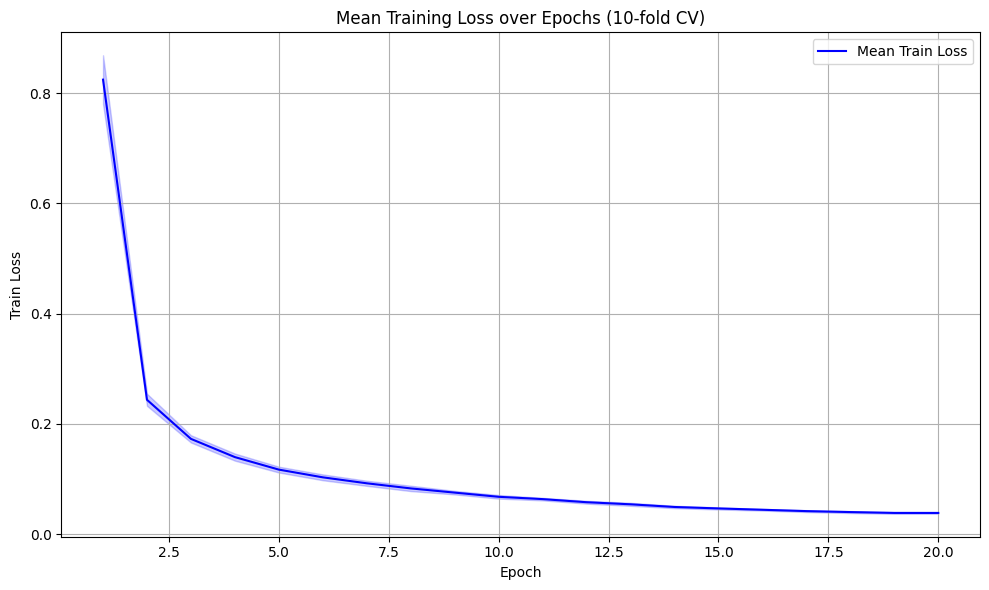

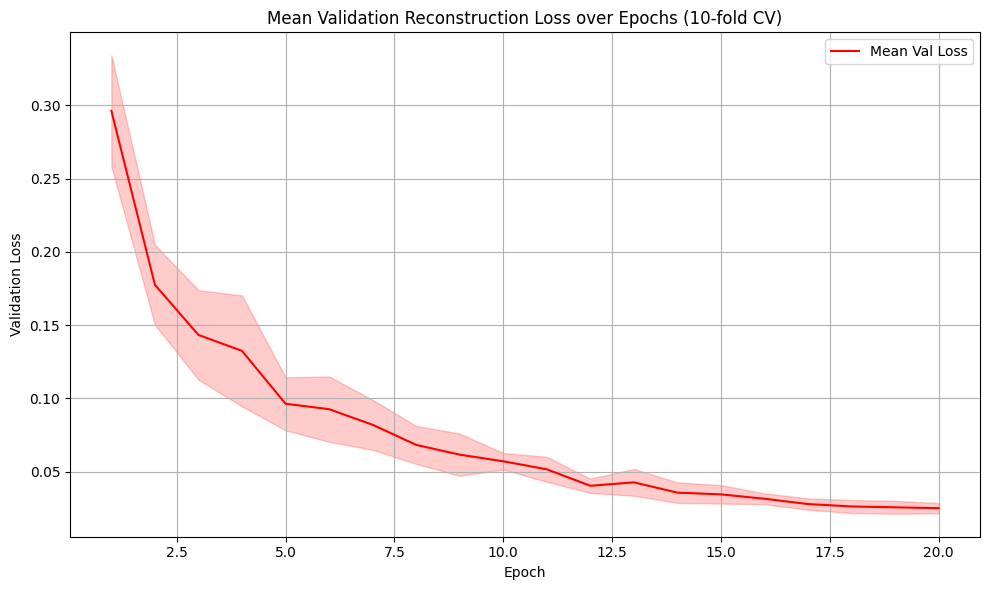

In [13]:
from sklearn.model_selection import GroupShuffleSplit


# Use sequence-level metadata
seq_meta = train_df.groupby("sequence_id").agg(
    subject=("subject", "first"),
    y_multi=("y_multi", "first"),
    y_bin=("y_bin", "first")
).reset_index()


# ---------------------------
# HOLD-OUT TEST SPLIT (20%)
# ---------------------------
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

trainval_idx, test_idx = next(
    gss.split(
        seq_meta["sequence_id"],
        groups=seq_meta["subject"]
    )
)

trainval_seq_ids = seq_meta.iloc[trainval_idx]["sequence_id"].values
test_seq_ids     = seq_meta.iloc[test_idx]["sequence_id"].values

# Actual DataFrames
trainval_df = train_df[train_df["sequence_id"].isin(trainval_seq_ids)].copy()
test_df_heldout = train_df[train_df["sequence_id"].isin(test_seq_ids)].copy()

print("Train+Val sequences:", trainval_df["sequence_id"].nunique())
print("TEST sequences:", test_df_heldout["sequence_id"].nunique())


seq_meta = trainval_df.groupby("sequence_id").agg(
    subject=("subject", "first"),
    y_multi=("y_multi", "first"),
    y_bin=("y_bin", "first")
).reset_index()



BEST_MODEL_PATH = "models/best_model_AE.pt"

os.makedirs("models/", exist_ok=True)

# Biến theo dõi
global_best_val_loss = float("inf")
best_model_state = None


seq_ids  = seq_meta["sequence_id"].values
subjects = seq_meta["subject"].values

gkf = GroupKFold(n_splits=10)
fold_scores = []
all_fold_train_losses = []  
all_fold_val_losses = []    

for fold, (tr_idx, val_idx) in enumerate(gkf.split(seq_ids, groups=subjects), start=1):
    print(f"\n========== FOLD {fold} ==========")
    train_seq_ids = seq_ids[tr_idx]
    val_seq_ids   = seq_ids[val_idx]

    fold_train_df = trainval_df[trainval_df["sequence_id"].isin(train_seq_ids)].copy()
    fold_val_df   = trainval_df[trainval_df["sequence_id"].isin(val_seq_ids)].copy()

    print("  #seq train:", fold_train_df["sequence_id"].nunique(),
          "- #seq val:", fold_val_df["sequence_id"].nunique())
    
    

    y_multi_train = seq_meta.iloc[tr_idx]["y_multi"].values
    class_counts  = np.bincount(y_multi_train, minlength=num_classes).astype(np.float32)
    class_weights = 1.0 / (class_counts + 1e-3)
    class_weights = class_weights / class_weights.mean()
    class_weights_t = torch.tensor(class_weights, dtype=torch.float32, device=device)

    y_bin_train = seq_meta.iloc[tr_idx]["y_bin"].values
    pos_count = y_bin_train.sum()
    neg_count = len(y_bin_train) - pos_count
    if pos_count == 0 or neg_count == 0:
        pos_weight_val = 1.0
    else:
        pos_weight_val = neg_count / max(pos_count, 1)
    pos_weight_t = torch.tensor(pos_weight_val, dtype=torch.float32, device=device)

    train_dataset = IMUOnlyDataset(
        fold_train_df,
        is_train=True,
        augment=True,        
        mixup_prob=0.3,
    )
    val_dataset   = IMUOnlyDataset(
        fold_val_df,
        is_train=True,
        augment=False,        
        mixup_prob=0.0,
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=32,
        shuffle=True,
        collate_fn=imu_only_collate_fn
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=32,
        shuffle=False,
        collate_fn=imu_only_collate_fn
    )

    print(len(train_dataset),len(val_dataset))

    EPOCHS = 20
    train_losses = []
    val_losses = []

    model = ResNet1DAutoEncoder(
        in_ch=len(IMU_BASE_COLS),
        latent_dim=32
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(), lr=5e-4, weight_decay=1e-4
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=EPOCHS
    )

    best_val_loss = float("inf")
    best_model_state = None

    for epoch in range(1, EPOCHS + 1):
        print(f"\nEPOCH {epoch}/{EPOCHS}")

        train_loss = train_one_epoch(
            model, train_loader, optimizer, device
        )
        val_loss = eval_one_epoch(
            model, val_loader, device
        )

        scheduler.step()

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Train Loss: {train_loss:.5f} | Val Loss: {val_loss:.5f}")

        # Save best model (per fold)
        if val_loss < global_best_val_loss:
            best_val_loss = val_loss
            global_best_val_loss=val_loss
            best_model_state = {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_loss": val_loss,
            }    
        
            torch.save(best_model_state, BEST_MODEL_PATH)

    

    all_fold_train_losses.append(train_losses)
    all_fold_val_losses.append(val_losses)



all_fold_train_losses = np.array(all_fold_train_losses)  # (F, E)
all_fold_val_losses   = np.array(all_fold_val_losses)

mean_train_losses = all_fold_train_losses.mean(axis=0)
std_train_losses  = all_fold_train_losses.std(axis=0)

mean_val_losses = all_fold_val_losses.mean(axis=0)
std_val_losses  = all_fold_val_losses.std(axis=0)

epochs = np.arange(1, EPOCHS + 1)


fig1, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(epochs, mean_train_losses, label="Mean Train Loss", color="blue")
ax1.fill_between(
    epochs,
    mean_train_losses - std_train_losses,
    mean_train_losses + std_train_losses,
    color="blue",
    alpha=0.2
)

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Train Loss")
ax1.set_title("Mean Training Loss over Epochs (10-fold CV)")
ax1.legend()
ax1.grid(True)

plt.tight_layout()
plt.show()



fig2, ax2 = plt.subplots(figsize=(10, 6))

ax2.plot(epochs, mean_val_losses, label="Mean Val Loss", color="red")
ax2.fill_between(
    epochs,
    mean_val_losses - std_val_losses,
    mean_val_losses + std_val_losses,
    color="red",
    alpha=0.2
)

ax2.set_xlabel("Epoch")
ax2.set_ylabel("Validation Loss")
ax2.set_title("Mean Validation Reconstruction Loss over Epochs (10-fold CV)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


In [14]:
checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)

model = ResNet1DAutoEncoder(
    in_ch=len(IMU_BASE_COLS),
    latent_dim=32
).to(device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

# Freeze encoder for probing
for p in model.encoder.parameters():
    p.requires_grad = False

In [15]:
test_dataset = IMUOnlyDataset(
    test_df_heldout,
    is_train=False,
    augment=False,
    mixup_prob=0.0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=imu_only_collate_fn
)

In [21]:
all_z_test = []
all_feat_test = []   # engineered features (for probes)
all_seq_ids = []

model.eval()
with torch.no_grad():
    for (
        x_imu_base,
        lengths,
        x_imu_feat,
        y_bin,
        y_multi,
        subjects,
        seq_ids,
    ) in test_loader:

        x_imu_base = x_imu_base.to(device)
        _, z = model(x_imu_base)   # (B, T, latent_dim)

        for i in range(z.shape[0]):
            T = lengths[i].item()

            zi = z[i, :T].cpu()               # (T, latent_dim)
            fi = x_imu_feat[i, :T]            # (T, D_feat)

            all_z_test.append(zi)
            all_feat_test.append(fi)
            all_seq_ids.extend([seq_ids[i]] * T)

# Now safe to concatenate
Z_test = torch.cat(all_z_test, dim=0)          # (N_total_timesteps, latent_dim)
F_test = torch.cat(all_feat_test, dim=0)       # (N_total_timesteps, D_feat)

print(Z_test.shape, F_test.shape)

torch.Size([124371, 32]) torch.Size([124371, 20])


In [22]:
# Example: probe angular velocity
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

# Suppose angular velocity indices in IMU_FEATURE_NAMES
ang_vel_idx = [
    IMU_FEATURE_NAMES.index("angular_vel_x"),
    IMU_FEATURE_NAMES.index("angular_vel_y"),
    IMU_FEATURE_NAMES.index("angular_vel_z"),
]

Y_ang = F_test[:, ang_vel_idx].numpy()
Z_lat = Z_test.numpy()

probe = Ridge(alpha=1.0)
probe.fit(Z_lat, Y_ang)
Y_pred = probe.predict(Z_lat)

print("Angular velocity R²:", r2_score(Y_ang, Y_pred, multioutput="uniform_average"))

Angular velocity R²: 0.1282026171684265


In [23]:
# angular velocity from engineered features (sanity check)
Y_ang = F_test[:, ang_vel_idx].numpy()
X_feat = F_test.numpy()

probe_feat = Ridge(alpha=1.0)
probe_feat.fit(X_feat, Y_ang)
Y_pred_feat = probe_feat.predict(X_feat)

print("Feature → angular vel R²:",
      r2_score(Y_ang, Y_pred_feat, multioutput="uniform_average"))

Feature → angular vel R²: 1.0


In [24]:
# Raw IMU baseline
raw_idx = [
    IMU_FEATURE_NAMES.index("acc_x"),
    IMU_FEATURE_NAMES.index("acc_y"),
    IMU_FEATURE_NAMES.index("acc_z"),
]

X_raw = F_test[:, raw_idx].numpy()

probe_raw = Ridge(alpha=1.0)
probe_raw.fit(X_raw, Y_ang)
Y_pred_raw = probe_raw.predict(X_raw)

print("Raw acc → angular vel R²:",
      r2_score(Y_ang, Y_pred_raw, multioutput="uniform_average"))

Raw acc → angular vel R²: 0.031224310398101807
